# Set-up

In [3]:
# Install requirements
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 40.4 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]


In [1]:
# Import packages

import os, sys, json, glob, time, argparse
from math import ceil
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import rasterio
from rasterio.merge import merge as rio_merge
from rasterio.enums import Resampling
from tqdm import tqdm
import yaml
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import os
import glob
import torch
import yaml
import json
import time
import rasterio
from rasterio.merge import merge as rio_merge
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from rasterio.warp import reproject, Resampling

/cs/student/projects2/aisd/2024/tcannon/dissertation/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
# Project imports 

from data.dataset import LidarS2Dataset
from models.unet import ConditionalUNet
from diffusion.scheduler import LinearDiffusionScheduler, CosineDiffusionScheduler
from diffusion.sampling import p_sample_loop_ddpm, p_sample_loop_ddim, p_sample_loop_plms

# Figure Building

In [6]:
# --------------------------
# Utility helpers
# --------------------------
def load_checkpoint(ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    cfg = ckpt.get("config", None)
    state = ckpt["model_state_dict"]
    return state, cfg, ckpt

def find_stats_file(s2_dir):
    cand = os.path.join(s2_dir, "s2_stats_24.pt")
    return cand if os.path.exists(cand) else None

def list_all_patch_ids(s2_dir):
    return sorted([
        os.path.basename(p).split('_')[-1]
        for p in glob.glob(os.path.join(s2_dir, "s2_patch_*"))
        if os.path.isdir(p)
    ])

def find_lidar_patch(lidar_dir, tile_id):
    cands = glob.glob(os.path.join(lidar_dir, f"*{tile_id}*.tif"))
    if not cands:
        raise FileNotFoundError(f"No LiDAR patch found for tile_id={tile_id} in {lidar_dir}")
    ones = [c for c in cands if "1m" in os.path.basename(c)]
    return (ones[0] if ones else cands[0])

def get_patch_ids_subset(s2_dir, region_ids=None, max_tiles=None, seed=42, deterministic_order=True):
    pids = list_all_patch_ids(s2_dir)
    if region_ids is not None:
        region_ids = set(region_ids)
        filtered = []
        for pid in pids:
            rj = os.path.join(s2_dir, f"s2_patch_{pid}", "region.json")
            try:
                with open(rj, "r") as f:
                    rid = json.load(f).get("region_id", None)
                if rid in region_ids:
                    filtered.append(pid)
            except Exception:
                pass
        pids = filtered
    if (max_tiles is not None) and (len(pids) > max_tiles):
        if deterministic_order:
            pids = pids[:max_tiles]
        else:
            rng = np.random.default_rng(seed)
            pids = list(rng.choice(pids, size=max_tiles, replace=False))
    return pids

def write_tif_like(ref_tif, out_path, array_2d_float32):
    with rasterio.open(ref_tif) as ref:
        prof = ref.profile.copy()
    prof.update(dtype="float32", count=1, compress="deflate", predictor=3, tiled=True,
                blockxsize=min(256, prof["width"]), blockysize=min(256, prof["height"]),
                BIGTIFF="IF_SAFER")
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with rasterio.open(out_path, "w", **prof) as dst:
        dst.write(array_2d_float32.astype(np.float32), 1)

def mosaic_average_safe(tif_list, out_path, compress=None):
    assert len(tif_list) > 0, "No input tiles to mosaic."
    srcs = [rasterio.open(fp) for fp in tif_list]
    try:
        nodatas = [s.nodata for s in srcs]
        merge_kwargs = {}
        if all(nd == nodatas[0] for nd in nodatas) and (nodatas[0] is not None):
            merge_kwargs["nodata"] = nodatas[0]
        sum_arr, transform = rio_merge(srcs, method="sum", **merge_kwargs)
        cnt_arr, _         = rio_merge(srcs, method="count", **merge_kwargs)
        denom = np.maximum(cnt_arr.astype(np.float32), 1.0)
        avg2d = (sum_arr.astype(np.float32) / denom)[0]
        ref = srcs[0]
        prof = {
            "driver": "GTiff",
            "height": int(avg2d.shape[0]),
            "width":  int(avg2d.shape[1]),
            "count":  1,
            "dtype":  "float32",
            "crs":    ref.crs,
            "transform": transform,
            "tiled": False,
        }
        if merge_kwargs.get("nodata", None) is not None:
            prof["nodata"] = merge_kwargs["nodata"]
        if compress:
            prof["compress"] = compress
        try:
            from rasterio.shutil import delete as rio_delete
            if os.path.exists(out_path):
                rio_delete(out_path)
        except Exception:
            if os.path.exists(out_path):
                os.remove(out_path)
        with rasterio.open(out_path, "w", **prof) as dst:
            dst.write(avg2d, 1)
    finally:
        for s in srcs:
            s.close()
    return out_path

def plot_lidar_3d_surface(lidar_array, title="3D LiDAR Surface Plot"):
    lidar_array = np.where(np.isnan(lidar_array), 0, lidar_array)
    height, width = lidar_array.shape
    x_coords = np.arange(0, width)
    y_coords = np.arange(0, height)
    X, Y = np.meshgrid(x_coords, y_coords)
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    surface = ax.plot_surface(
        X, Y, lidar_array,
        cmap='terrain',
        alpha=0.9,
        edgecolor='none',
        rstride=1, cstride=1
    )
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Elevation Deviations (m)')
    ax.set_title(title)
    fig.colorbar(surface, ax=ax, shrink=0.5, aspect=5, label='Elevation Deviations (m)')
    ax.view_init(elev=15, azim=70)
    plt.show()

def subsample(arr, step):
    return arr[::step, ::step]

In [7]:
# --------------------------
# Core: batch predict tiles then mosaic + 3D
# --------------------------
# --------------------------
# Core: batch predict tiles then mosaic + 3D
# --------------------------
@torch.no_grad()
def predict_and_plot_predicted_map(
    ckpt_path, config_yaml, out_dir,
    sampler_name="ddpm", batch_size=8, num_workers=4, device="cuda",
    region_ids=None, max_tiles=None, seed=42, deterministic_order=True
):
    os.makedirs(out_dir, exist_ok=True)
    device = torch.device(device if torch.cuda.is_available() else "cpu")

    state, cfg_from_ckpt, _ = load_checkpoint(ckpt_path, device)
    if config_yaml:
        with open(config_yaml, "r") as f:
            cfg = yaml.safe_load(f)
            print("Loaded config from", config_yaml)
    else:
        cfg = cfg_from_ckpt

    s2_dir = cfg["data"]["s2_dir"]
    lidar_dir = cfg["data"]["lidar_dir"]
    context_k = cfg["training"]["context_k"]
    noise_sched = cfg["training"]["noise_schedule"]
    timesteps = cfg["training"]["timesteps"]
    base_channels = cfg["model"]["base_channels"]
    embed_dim = cfg["model"]["embed_dim"]
    unet_depth = cfg["model"]["unet_depth"]
    attention_variant = cfg["model"]["attention_variant"]

    print("\n=== Inference Config ===")
    print(f"S2 dir:    {s2_dir}")
    print(f"LiDAR dir: {lidar_dir}")
    print(f"Checkpoint: {ckpt_path}")
    print(f"Sampler: {sampler_name} | Timesteps: {timesteps} | Schedule: {noise_sched}")
    print(f"Model: UNet depth={unet_depth}, base={base_channels}, attn={attention_variant}, embed_dim={embed_dim}")
    print(f"Context k: {context_k}\n")

    if noise_sched == "linear":
        scheduler = LinearDiffusionScheduler(timesteps=timesteps, device=device)
    else:
        scheduler = CosineDiffusionScheduler(timesteps=timesteps, device=device)

    model = ConditionalUNet(
        in_channels=1,
        cond_channels=4 * context_k,
        attr_dim=8 * context_k,
        base_channels=base_channels,
        embed_dim=embed_dim,
        unet_depth=unet_depth,
        attention_variant=attention_variant
    ).to(device)
    model.load_state_dict(state)
    model.eval()

    stats_path = find_stats_file(s2_dir)
    if stats_path:
        stats = torch.load(stats_path, map_location="cpu")
        s2_means, s2_stds = stats["mean"], stats["std"]
    else:
        raise FileNotFoundError(f"Could not find S2 stats file (expected at {os.path.join(s2_dir, 's2_stats_24.pt')}).")

    subset_pids = get_patch_ids_subset(
        s2_dir=s2_dir,
        region_ids=region_ids,
        max_tiles=max_tiles,
        seed=seed,
        deterministic_order=deterministic_order
    )
    print(f"Using {len(subset_pids)} patch(es). Example: {subset_pids[:5]} ...")

    dataset = LidarS2Dataset(
        lidar_dir=lidar_dir,
        s2_dir=s2_dir,
        s2_means=s2_means,
        s2_stds=s2_stds,
        context_k=context_k,
        randomize_context=False,
        augment=False,
        debug=False,
        split_pids=subset_pids,
        split="val"
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    samplers = {
        "ddpm": lambda m, s, c, a, d: p_sample_loop_ddpm(m, scheduler, s, c, a, d),
        "ddim": lambda m, s, c, a, d: p_sample_loop_ddim(m, scheduler, s, c, a, d),
        "plms": lambda m, s, c, a, d: p_sample_loop_plms(m, scheduler, s, c, a, d),
    }
    sampler = samplers[sampler_name]

    pred_tiles_dir = os.path.join(out_dir, "pred_tiles")
    os.makedirs(pred_tiles_dir, exist_ok=True)
    pred_tifs = []

    start = time.perf_counter()
    for batch in tqdm(loader, desc="Predicting tiles"):
        s2 = batch["s2"].to(device)
        attrs = batch["attrs"].to(device)
        lidar = batch["lidar"].to(device)
        tile_ids_batch = batch["tile_id"]

        pred = sampler(model, lidar.shape, s2, attrs, device)
        pred = pred.float().cpu().numpy()

        B = pred.shape[0]
        for i in range(B):
            tile_id = tile_ids_batch[i]
            gt_lidar_tif = find_lidar_patch(lidar_dir, tile_id)
            out_tif = os.path.join(pred_tiles_dir, f"pred_{tile_id}.tif")
            write_tif_like(gt_lidar_tif, out_tif, pred[i, 0])
            pred_tifs.append(out_tif)

    elapsed = time.perf_counter() - start
    print(f"\nFinished per-tile predictions for {len(pred_tifs)} tiles in {elapsed / 60:.1f} min.")

    pred_mosaic_path = os.path.join(out_dir, "pred_mosaic.tif")
    print("Mosaicking predictions →", pred_mosaic_path)
    mosaic_average_safe(pred_tifs, pred_mosaic_path, compress="deflate")

    # Load and plot the predicted mosaic
    with rasterio.open(pred_mosaic_path) as src:
        predicted_array = src.read(1)
        # Downsample the array for faster plotting
        downsampled_array = subsample(predicted_array, step=4)
        plot_lidar_3d_surface(downsampled_array, title="Predicted LiDAR Elevation Map")

    return {
        "pred_mosaic": pred_mosaic_path
    }


=== Inference Config ===
S2 dir:    /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/final/s2_patches_multi
LiDAR dir: /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/final/lidar_patches
Checkpoint: /cs/student/projects2/aisd/2024/tcannon/dissertation/models/exp1_narrow_mid_k1_att_best.pth
Sampler: plms | Timesteps: 1000 | Schedule: cosine
Model: UNet depth=4, base=64, attn=mid, embed_dim=256
Context k: 1

Using 16 patch(es). Example: ['01848', '01849', '01850', '01851', '01852'] ...
Prepared 16 matched LiDAR↔6×S2 groups.


Predicting tiles: 100%|██████████| 2/2 [01:47<00:00, 53.64s/it]



Finished per-tile predictions for 16 tiles in 1.8 min.
Mosaicking predictions → /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/final/mod_final/diagrams/pred_mosaic.tif


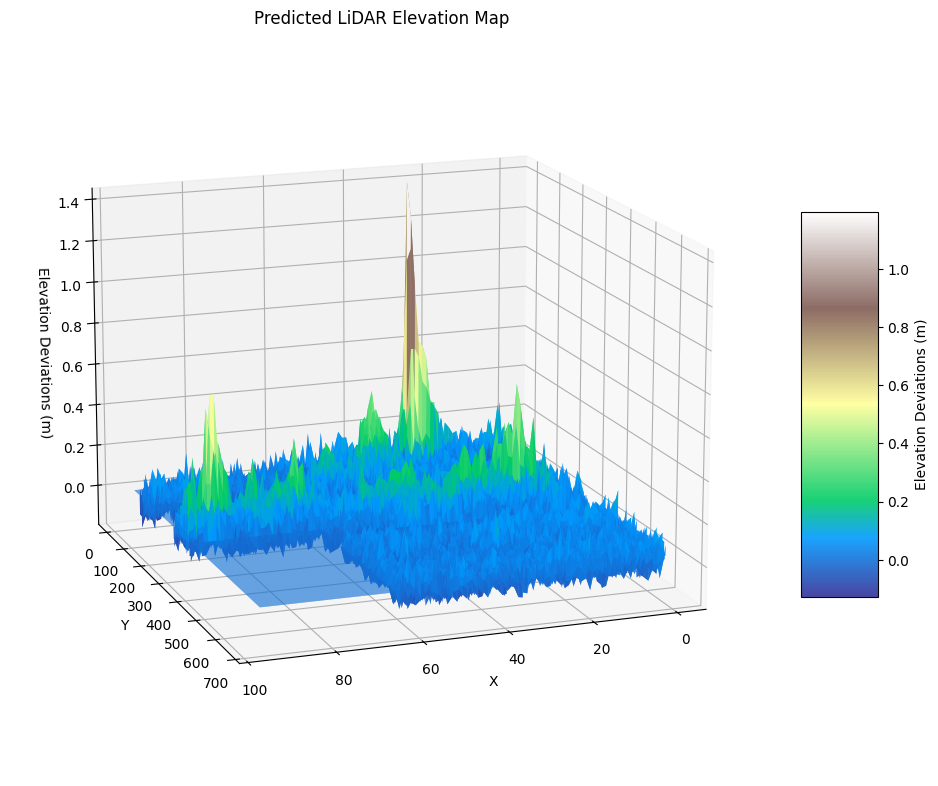


Done.


In [8]:
# Execution
# --------------------------
results = predict_and_plot_predicted_map(
    ckpt_path='/cs/student/projects2/aisd/2024/tcannon/dissertation/models/exp1_narrow_mid_k1_att_best.pth',
    config_yaml=None,
    out_dir='/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/final/mod_final/diagrams',
    sampler_name='plms',
    batch_size=8,
    num_workers=16,
    device='cuda',
    region_ids=[4],
    max_tiles=16,
    seed=42,
    deterministic_order=True
)
print("\nDone.")


=== Inference Config ===
S2 dir:    /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/final/s2_patches_multi
LiDAR dir: /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/final/lidar_patches
Checkpoint: /cs/student/projects2/aisd/2024/tcannon/dissertation/models/exp1_narrow_mid_k1_att_best.pth
Sampler: plms | Timesteps: 1000 | Schedule: cosine
Model: UNet depth=4, base=64, attn=mid, embed_dim=256
Context k: 1

Using 64 patch(es). Example: ['01848', '01849', '01850', '01851', '01852'] ...
Prepared 64 matched LiDAR↔6×S2 groups.


Predicting tiles: 100%|██████████| 8/8 [06:02<00:00, 45.35s/it]



Finished per-tile predictions for 64 tiles in 6.0 min.
Mosaicking predictions → /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/final/mod_final/diagrams/pred_mosaic.tif
Mosaicking ground truth → /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/final/mod_final/diagrams/gt_mosaic.tif
Wrote diff raster → /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/final/mod_final/diagrams/diff_pred_minus_gt.tif
Saved 3D plots to /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/final/mod_final/diagrams/combined_3d_plots.png


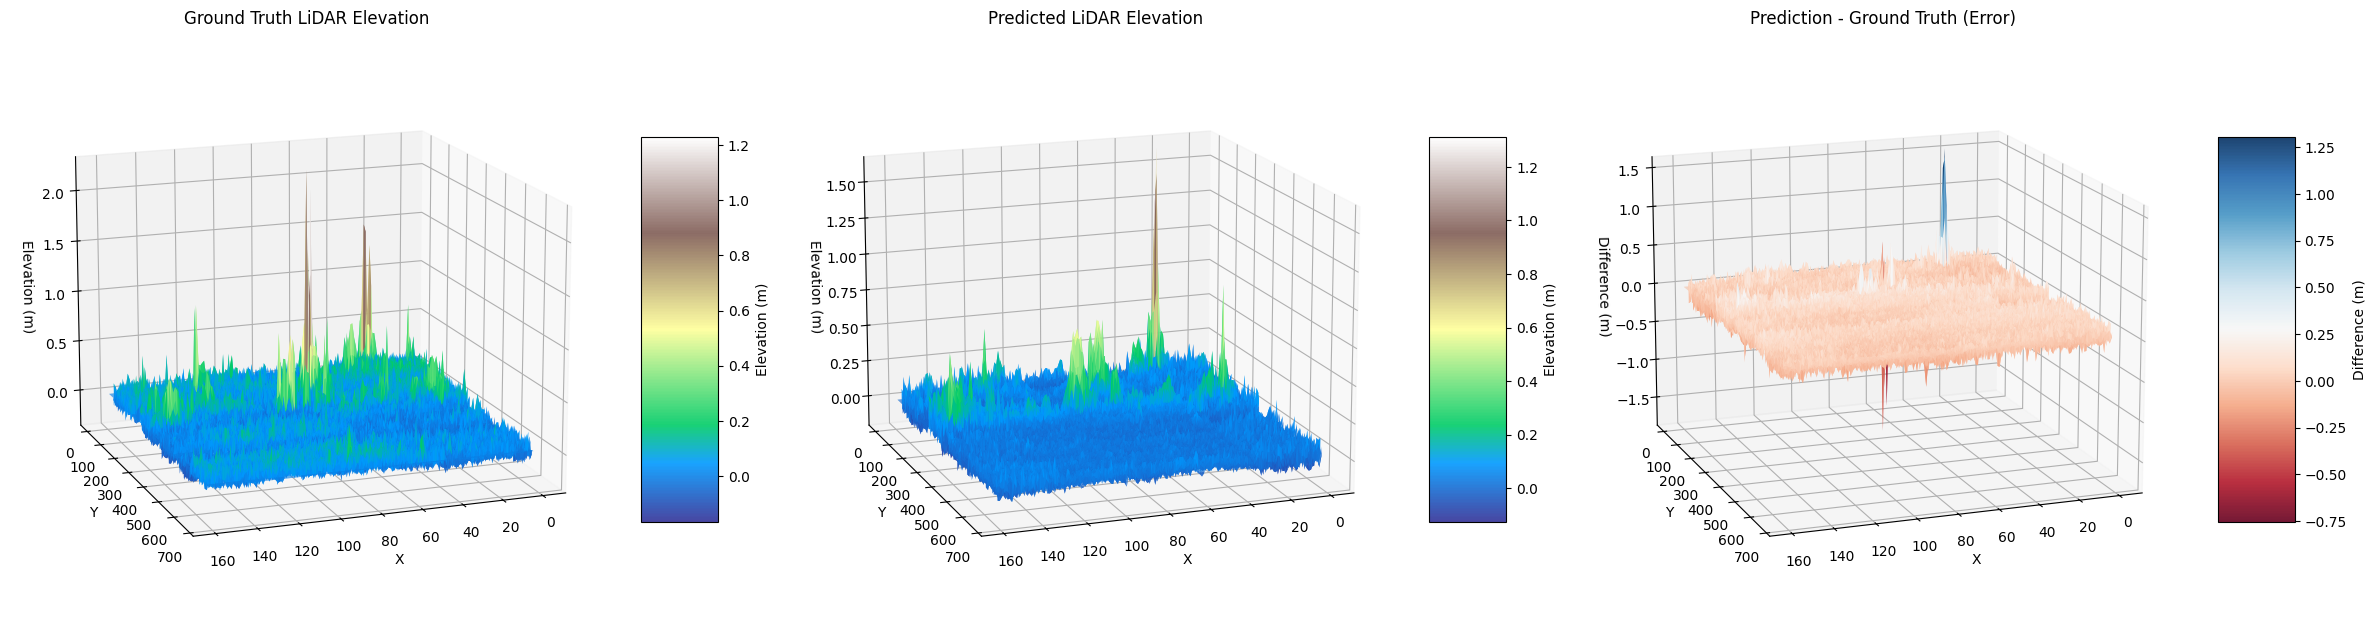


Done.


In [ ]:


# Your utility helpers (load_checkpoint, find_stats_file, etc.) go here.
def load_checkpoint(ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    cfg = ckpt.get("config", None)
    state = ckpt["model_state_dict"]
    return state, cfg, ckpt

def find_stats_file(s2_dir):
    cand = os.path.join(s2_dir, "s2_stats_24.pt")
    return cand if os.path.exists(cand) else None

def list_all_patch_ids(s2_dir):
    return sorted([
        os.path.basename(p).split('_')[-1]
        for p in glob.glob(os.path.join(s2_dir, "s2_patch_*"))
        if os.path.isdir(p)
    ])

def find_lidar_patch(lidar_dir, tile_id):
    cands = glob.glob(os.path.join(lidar_dir, f"*{tile_id}*.tif"))
    if not cands:
        raise FileNotFoundError(f"No LiDAR patch found for tile_id={tile_id} in {lidar_dir}")
    ones = [c for c in cands if "1m" in os.path.basename(c)]
    return (ones[0] if ones else cands[0])

def get_patch_ids_subset(s2_dir, region_ids=None, max_tiles=None, seed=42, deterministic_order=True):
    pids = list_all_patch_ids(s2_dir)
    if region_ids is not None:
        region_ids = set(region_ids)
        filtered = []
        for pid in pids:
            rj = os.path.join(s2_dir, f"s2_patch_{pid}", "region.json")
            try:
                with open(rj, "r") as f:
                    rid = json.load(f).get("region_id", None)
                if rid in region_ids:
                    filtered.append(pid)
            except Exception:
                pass
        pids = filtered
    if (max_tiles is not None) and (len(pids) > max_tiles):
        if deterministic_order:
            pids = pids[:max_tiles]
        else:
            rng = np.random.default_rng(seed)
            pids = list(rng.choice(pids, size=max_tiles, replace=False))
    return pids

def write_tif_like(ref_tif, out_path, array_2d_float32):
    with rasterio.open(ref_tif) as ref:
        prof = ref.profile.copy()
    prof.update(dtype="float32", count=1, compress="deflate", predictor=3, tiled=True,
                blockxsize=min(256, prof["width"]), blockysize=min(256, prof["height"]),
                BIGTIFF="IF_SAFER")
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with rasterio.open(out_path, "w", **prof) as dst:
        dst.write(array_2d_float32.astype(np.float32), 1)

def mosaic_average_safe(tif_list, out_path, compress=None):
    assert len(tif_list) > 0, "No input tiles to mosaic."
    srcs = [rasterio.open(fp) for fp in tif_list]
    try:
        nodatas = [s.nodata for s in srcs]
        merge_kwargs = {}
        if all(nd == nodatas[0] for nd in nodatas) and (nodatas[0] is not None):
            merge_kwargs["nodata"] = nodatas[0]
        sum_arr, transform = rio_merge(srcs, method="sum", **merge_kwargs)
        cnt_arr, _         = rio_merge(srcs, method="count", **merge_kwargs)
        denom = np.maximum(cnt_arr.astype(np.float32), 1.0)
        avg2d = (sum_arr.astype(np.float32) / denom)[0]
        ref = srcs[0]
        prof = {
            "driver": "GTiff",
            "height": int(avg2d.shape[0]),
            "width":  int(avg2d.shape[1]),
            "count":  1,
            "dtype":  "float32",
            "crs":    ref.crs,
            "transform": transform,
            "tiled": False,
        }
        if merge_kwargs.get("nodata", None) is not None:
            prof["nodata"] = merge_kwargs["nodata"]
        if compress:
            prof["compress"] = compress
        try:
            from rasterio.shutil import delete as rio_delete
            if os.path.exists(out_path):
                rio_delete(out_path)
        except Exception:
            if os.path.exists(out_path):
                os.remove(out_path)
        with rasterio.open(out_path, "w", **prof) as dst:
            dst.write(avg2d, 1)
    finally:
        for s in srcs:
            s.close()
    return out_path

def subsample(arr, step):
    return arr[::step, ::step]

# Modified plotting function to return ax and surface for multi-plot figures
def plot_single_3d_surface(ax, lidar_array, title="3D LiDAR Surface Plot", cmap='terrain', z_label='Elevation Deviations (m)'):
    #lidar_array = np.where(np.isnan(lidar_array), 0, lidar_array)
    height, width = lidar_array.shape
    x_coords = np.arange(0, width)
    y_coords = np.arange(0, height)
    X, Y = np.meshgrid(x_coords, y_coords)

    surface = ax.plot_surface(
        X, Y, lidar_array,
        cmap=cmap,
        alpha=0.9,
        edgecolor='none',
        rstride=1, cstride=1
    )
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel(z_label)
    ax.set_title(title)
    ax.view_init(elev=15, azim=70) # Controls perspective
    return surface

def plot_all_three_3d_surfaces(gt_array, pred_array, diff_array, step=4, out_path=None):
    # Decimate for interactive surface
    gt_s = subsample(gt_array, step)
    pr_s = subsample(pred_array, step)
    diff_s = subsample(diff_array, step)

    fig = plt.figure(figsize=(24, 8)) # Wider figure for 3 plots

    # Plot 1: Ground Truth
    ax1 = fig.add_subplot(1, 3, 1, projection='3d')
    surface1 = plot_single_3d_surface(ax1, gt_s, title="Ground Truth LiDAR Elevation", cmap='terrain', z_label='Elevation (m)')
    fig.colorbar(surface1, ax=ax1, shrink=0.5, aspect=5, label='Elevation (m)')

    # Plot 2: Prediction
    ax2 = fig.add_subplot(1, 3, 2, projection='3d')
    surface2 = plot_single_3d_surface(ax2, pr_s, title="Predicted LiDAR Elevation", cmap='terrain', z_label='Elevation (m)')
    fig.colorbar(surface2, ax=ax2, shrink=0.5, aspect=5, label='Elevation (m)')

    # Plot 3: Difference (Error Map)
    ax3 = fig.add_subplot(1, 3, 3, projection='3d')
    surface3 = plot_single_3d_surface(ax3, diff_s, title="Prediction - Ground Truth (Error)", cmap='RdBu', z_label='Difference (m)')
    fig.colorbar(surface3, ax=ax3, shrink=0.5, aspect=5, label='Difference (m)')

    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, bbox_inches='tight', dpi=300)
        print(f"Saved 3D plots to {out_path}")
    plt.show()


# --------------------------
# Core: batch predict tiles then mosaic + 3D
# --------------------------
@torch.no_grad()
def predict_and_plot_all_maps(
    ckpt_path, config_yaml, out_dir,
    sampler_name="ddpm", batch_size=8, num_workers=4, device="cuda",
    region_ids=None, max_tiles=None, seed=42, deterministic_order=True
):
    os.makedirs(out_dir, exist_ok=True)
    device = torch.device(device if torch.cuda.is_available() else "cpu")

    state, cfg_from_ckpt, _ = load_checkpoint(ckpt_path, device)
    if config_yaml:
        with open(config_yaml, "r") as f:
            cfg = yaml.safe_load(f)
            print("Loaded config from", config_yaml)
    else:
        cfg = cfg_from_ckpt

    s2_dir = cfg["data"]["s2_dir"]
    lidar_dir = cfg["data"]["lidar_dir"]
    context_k = cfg["training"]["context_k"]
    noise_sched = cfg["training"]["noise_schedule"]
    timesteps = cfg["training"]["timesteps"]
    base_channels = cfg["model"]["base_channels"]
    embed_dim = cfg["model"]["embed_dim"]
    unet_depth = cfg["model"]["unet_depth"]
    attention_variant = cfg["model"]["attention_variant"]

    print("\n=== Inference Config ===")
    print(f"S2 dir:    {s2_dir}")
    print(f"LiDAR dir: {lidar_dir}")
    print(f"Checkpoint: {ckpt_path}")
    print(f"Sampler: {sampler_name} | Timesteps: {timesteps} | Schedule: {noise_sched}")
    print(f"Model: UNet depth={unet_depth}, base={base_channels}, attn={attention_variant}, embed_dim={embed_dim}")
    print(f"Context k: {context_k}\n")

    if noise_sched == "linear":
        scheduler = LinearDiffusionScheduler(timesteps=timesteps, device=device)
    else:
        scheduler = CosineDiffusionScheduler(timesteps=timesteps, device=device)

    model = ConditionalUNet(
        in_channels=1,
        cond_channels=4 * context_k,
        attr_dim=8 * context_k,
        base_channels=base_channels,
        embed_dim=embed_dim,
        unet_depth=unet_depth,
        attention_variant=attention_variant
    ).to(device)
    model.load_state_dict(state)
    model.eval()

    stats_path = find_stats_file(s2_dir)
    if stats_path:
        stats = torch.load(stats_path, map_location="cpu")
        s2_means, s2_stds = stats["mean"], stats["std"]
    else:
        raise FileNotFoundError(f"Could not find S2 stats file (expected at {os.path.join(s2_dir, 's2_stats_24.pt')}).")

    subset_pids = get_patch_ids_subset(
        s2_dir=s2_dir,
        region_ids=region_ids,
        max_tiles=max_tiles,
        seed=seed,
        deterministic_order=deterministic_order
    )
    print(f"Using {len(subset_pids)} patch(es). Example: {subset_pids[:5]} ...")

    dataset = LidarS2Dataset(
        lidar_dir=lidar_dir,
        s2_dir=s2_dir,
        s2_means=s2_means,
        s2_stds=s2_stds,
        context_k=context_k,
        randomize_context=False,
        augment=False,
        debug=False,
        split_pids=subset_pids,
        split="val"
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    samplers = {
        "ddpm": lambda m, s, c, a, d: p_sample_loop_ddpm(m, scheduler, s, c, a, d),
        "ddim": lambda m, s, c, a, d: p_sample_loop_ddim(m, scheduler, s, c, a, d),
        "plms": lambda m, s, c, a, d: p_sample_loop_plms(m, scheduler, s, c, a, d),
    }
    sampler = samplers[sampler_name]

    pred_tiles_dir = os.path.join(out_dir, "pred_tiles")
    os.makedirs(pred_tiles_dir, exist_ok=True)

    pred_tifs = []
    gt_tifs   = [] # Re-introducing for ground truth mosaic

    start = time.perf_counter()
    for batch in tqdm(loader, desc="Predicting tiles"):
        s2 = batch["s2"].to(device)
        attrs = batch["attrs"].to(device)
        lidar = batch["lidar"].to(device)
        tile_ids_batch = batch["tile_id"]

        pred = sampler(model, lidar.shape, s2, attrs, device)
        pred = pred.float().cpu().numpy()

        B = pred.shape[0]
        for i in range(B):
            tile_id = tile_ids_batch[i]
            gt_lidar_tif = find_lidar_patch(lidar_dir, tile_id)
            out_tif = os.path.join(pred_tiles_dir, f"pred_{tile_id}.tif")
            write_tif_like(gt_lidar_tif, out_tif, pred[i, 0])
            pred_tifs.append(out_tif)
            gt_tifs.append(gt_lidar_tif) # Collect GT tifs again

    elapsed = time.perf_counter() - start
    print(f"\nFinished per-tile predictions for {len(pred_tifs)} tiles in {elapsed / 60:.1f} min.")

    pred_mosaic_path = os.path.join(out_dir, "pred_mosaic.tif")
    print("Mosaicking predictions →", pred_mosaic_path)
    mosaic_average_safe(pred_tifs, pred_mosaic_path, compress="deflate")

    gt_mosaic_path = os.path.join(out_dir, "gt_mosaic.tif")
    print("Mosaicking ground truth →", gt_mosaic_path)
    # Use sorted(set(gt_tifs)) to ensure unique and consistent order for mosaicking
    mosaic_average_safe(sorted(list(set(gt_tifs))), gt_mosaic_path, compress="deflate")

    # Load mosaics and compute difference
    with rasterio.open(gt_mosaic_path) as g, rasterio.open(pred_mosaic_path) as p:
        gt_array = g.read(1).astype(np.float32)
        pred_array = p.read(1).astype(np.float32)

        # Align if shapes/transforms differ slightly
        if (gt_array.shape != pred_array.shape) or (g.transform != p.transform):
            pred_aligned = np.zeros_like(gt_array, dtype=np.float32)
            reproject(
                source=pred_array, destination=pred_aligned,
                src_transform=p.transform, src_crs=p.crs,
                dst_transform=g.transform, dst_crs=g.crs,
                resampling=Resampling.bilinear
            )
            pred_array = pred_aligned

        diff_array = pred_array - gt_array

    # Save the difference map as a GeoTIFF
    diff_path = os.path.join(out_dir, "diff_pred_minus_gt.tif")
    with rasterio.open(gt_mosaic_path) as g: # Use gt_mosaic_path's profile for writing diff
        prof = g.profile.copy()
        prof.update(dtype="float32", count=1, compress="deflate")
        with rasterio.open(diff_path, "w", **prof) as dst:
            dst.write(diff_array.astype(np.float32), 1)
    print("Wrote diff raster →", diff_path)


    # Plot all three 3D surfaces
    plot_all_three_3d_surfaces(gt_array, pred_array, diff_array, step=4,
                               out_path=os.path.join(out_dir, "combined_3d_plots.png"))

    return {
        "pred_tiles_dir": pred_tiles_dir,
        "pred_mosaic": pred_mosaic_path,
        "gt_mosaic": gt_mosaic_path,
        "diff": diff_path,
        "combined_3d_plot": os.path.join(out_dir, "combined_3d_plots.png")
    }

# Execution
# --------------------------
results = predict_and_plot_all_maps(
    ckpt_path='/cs/student/projects2/aisd/2024/tcannon/dissertation/models/final_improved_baseline_k1_att_best.pth',
    config_yaml=None,
    out_dir='/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/final/mod_final/diagrams',
    sampler_name='plms',
    batch_size=8,
    num_workers=16,
    device='cuda',
    region_ids=[4],
    max_tiles=4615,
    seed=42,
    deterministic_order=True
)

print("\nDone.")

In [ ]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Utility Functions (re-pasted for self-contained code) ---
def subsample(arr, step):
    return arr[::step, ::step]

def plot_single_3d_surface(ax, lidar_array, title="3D LiDAR Surface Plot", cmap='terrain', z_label='Elevation Deviations (m)'):
    lidar_array = np.where(np.isnan(lidar_array), 0, lidar_array)
    height, width = lidar_array.shape
    x_coords = np.arange(0, width)
    y_coords = np.arange(0, height)
    X, Y = np.meshgrid(x_coords, y_coords)

    surface = ax.plot_surface(
        X, Y, lidar_array,
        cmap=cmap,
        alpha=0.9,
        edgecolor='none',
        rstride=1, cstride=1
    )
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel(z_label)
    ax.set_title(title)
    ax.view_init(elev=15, azim=70)
    return surface

def plot_all_three_3d_surfaces(gt_array, pred_array, diff_array, step=10000, out_path=None):
    gt_s = subsample(gt_array, step)
    pr_s = subsample(pred_array, step)
    diff_s = subsample(diff_array, step)

    fig = plt.figure(figsize=(24, 8))

    ax1 = fig.add_subplot(1, 3, 1, projection='3d')
    surface1 = plot_single_3d_surface(ax1, gt_s, title="Ground Truth LiDAR Elevation", cmap='terrain', z_label='Elevation (m)')
    fig.colorbar(surface1, ax=ax1, shrink=0.5, aspect=5, label='Elevation (m)')

    ax2 = fig.add_subplot(1, 3, 2, projection='3d')
    surface2 = plot_single_3d_surface(ax2, pr_s, title="Predicted LiDAR Elevation", cmap='terrain', z_label='Elevation (m)')
    fig.colorbar(surface2, ax=ax2, shrink=0.5, aspect=5, label='Elevation (m)')

    ax3 = fig.add_subplot(1, 3, 3, projection='3d')
    surface3 = plot_single_3d_surface(ax3, diff_s, title="Prediction - Ground Truth (Error)", cmap='RdBu', z_label='Difference (m)')
    fig.colorbar(surface3, ax=ax3, shrink=0.5, aspect=5, label='Difference (m)')

    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, bbox_inches='tight', dpi=300)
        print(f"Saved 3D plots to {out_path}")
    plt.show()

# --- Main Script to Load and Plot ---

def load_and_plot_mosaics(out_dir):
    """
    Loads saved mosaic GeoTIFF files and plots the 3D surfaces.
    """
    pred_mosaic_path = os.path.join(out_dir, "pred_mosaic.tif")
    gt_mosaic_path   = os.path.join(out_dir, "gt_mosaic.tif")
    diff_path        = os.path.join(out_dir, "diff_pred_minus_gt.tif")
    output_plot_path = os.path.join(out_dir, "recreated_3d_plots.png")

    if not all(os.path.exists(p) for p in [pred_mosaic_path, gt_mosaic_path, diff_path]):
        print("One or more required mosaic files not found. Please ensure the paths are correct.")
        return

    print("Loading saved mosaic files...")
    with rasterio.open(gt_mosaic_path) as src:
        gt_array = src.read(1)

    with rasterio.open(pred_mosaic_path) as src:
        pred_array = src.read(1)

    with rasterio.open(diff_path) as src:
        diff_array = src.read(1)
        
    print("Files loaded. Generating plots...")
    plot_all_three_3d_surfaces(
        gt_array=gt_array,
        pred_array=pred_array,
        diff_array=diff_array,
        step=4,
        out_path=output_plot_path
    )
    print("\nPlotting complete.")

# --- Execution ---
output_directory = '/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/final/mod_final/diagrams'
load_and_plot_mosaics(output_directory)

Loading saved mosaic files...
Files loaded. Generating plots...


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7f0ba5b072e0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 